## Part 1 - Training the neural Network

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib as ta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report,confusion_matrix


In [5]:
# Read the data
data = pd.read_csv('MLT03_data_EURUSD_data.csv', index_col=0, parse_dates=True)
df = data.copy()
df.head()
df.tail()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-12-24,1.137204,1.143838,1.137204,1.137281,1.137281,0
2018-12-25,1.140511,1.142204,1.137010,1.140394,1.140394,0
2018-12-26,1.141344,1.141944,1.137618,1.141553,1.141553,0
2018-12-27,1.136364,1.143432,1.135912,1.136131,1.136131,0
2018-12-28,1.143092,1.147315,1.143092,1.143105,1.143105,0


In [6]:
# Calculate Target Value
df['returns'] = np.log(df['Adj Close']/df['Adj Close'].shift(1))
df['target_value'] = np.where(df['returns'].shift(-1) > df['returns'], 1, -1)
df.head()

,Open,High,Low,Close,Adj Close,Volume,returns,target_value
Date,,,,,,,,
2009-12-31,1.434206,1.443897,1.431045,1.432706,1.432706,0,NaN,-1
2010-01-01,1.432706,1.440196,1.432706,1.438994,1.438994,0,0.004379,-1
2010-01-04,1.431004,1.445191,1.426208,1.442398,1.442398,0,0.002363,-1
2010-01-05,1.442710,1.448310,1.435194,1.436596,1.436596,0,-0.004031,1
2010-01-06,1.436596,1.443460,1.429123,1.440403,1.440403,0,0.002647,-1


In [7]:
# Feature Engineering
features_list = []
# Moving STD
for i in range(5,30,5):
    col_name = f"STD_{i}"
    df[col_name] = df['Close'].rolling(window=i).std()
    features_list.append(col_name)
    
# Moving Average
for i in range(10,30,5):
    col_name = f"Mean_{i}"
    df[col_name] = df['Close'].rolling(window=i).mean()
    features_list.append(col_name)
    
# Moving percentage change
for i in range(3,12,3):
    col_name = f"pct_{i}"
    df[col_name] = df['Close'].pct_change().rolling(window=i).sum()
    features_list.append(col_name)
    
# Intraday Price Movements
col_name = "CO"
df[col_name] = df['Close']-df['Open']
features_list.append(col_name)

features_list

['STD_5',
 'STD_10',
 'STD_15',
 'STD_20',
 'STD_25',
 'Mean_10',
 'Mean_15',
 'Mean_20',
 'Mean_25',
 'pct_3',
 'pct_6',
 'pct_9',
 'CO']

In [8]:
# Add more technical indicators like BBBANDS,MACD,SAR
df['upper_band'],df['middle_band'],df['lower_band'] = ta.BBANDS(df['Close'].values)
df['macd'],df['macd_signal'],df['macd_hist'] = ta.MACD(df['Close'].values)
df['SAR'] = ta.SAR(df['High'].values,df['Low'].values)

features_list+= ['upper_band','middle_band','lower_band','macd','SAR']
features_list

['STD_5',
 'STD_10',
 'STD_15',
 'STD_20',
 'STD_25',
 'Mean_10',
 'Mean_15',
 'Mean_20',
 'Mean_25',
 'pct_3',
 'pct_6',
 'pct_9',
 'CO',
 'upper_band',
 'middle_band',
 'lower_band',
 'macd',
 'SAR']

In [9]:
# Remove missing values
df = df.dropna()
df[features_list+['target_value']].head()

,STD_5,STD_10,STD_15,STD_20,STD_25,Mean_10,Mean_15,Mean_20,Mean_25,pct_3,pct_6,pct_9,CO,upper_band,middle_band,lower_band,macd,SAR,target_value
Date,,,,,,,,,,,,,,,,,,,
2010-02-16,0.007174,0.008744,0.013772,0.018470,0.027872,1.372029,1.379814,1.387765,1.398622,0.006298,0.008339,-0.009467,0.016979,1.381636,1.368802,1.355968,-0.020450,1.353308,-1
2010-02-17,0.006823,0.006695,0.012981,0.018562,0.026501,1.369088,1.376987,1.385247,1.394954,-0.001914,-0.012626,-0.009872,-0.015846,1.378081,1.365875,1.353669,-0.020266,1.353797,1
2010-02-18,0.010875,0.009546,0.014006,0.019568,0.025640,1.366253,1.373610,1.382070,1.390800,-0.010262,-0.021224,-0.015841,-0.014914,1.380923,1.361469,1.342016,-0.021051,1.378873,1
2010-02-19,0.010818,0.009634,0.013834,0.018543,0.024206,1.365603,1.371931,1.379440,1.387697,-0.010913,-0.004615,-0.002574,0.014452,1.380425,1.361072,1.341720,-0.020201,1.378873,-1
2010-02-22,0.010814,0.009766,0.012841,0.016977,0.022112,1.365113,1.369788,1.376718,1.384492,0.000027,-0.001887,-0.012599,-0.002337,1.380469,1.361124,1.341779,-0.019380,1.378196,-1


In [10]:
# Build and train the model
x = df[features_list]
y = df['target_value']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size = 0.2,shuffle = False)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1848, 18), (462, 18), (1848,), (462,))

In [11]:
# Scale them to have it normalized
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [29]:
model = MLPClassifier(hidden_layer_sizes=(5),activation='tanh',solver='adam',max_iter = 300,shuffle = False)
model.fit(x_train_scaled,y_train)

MLPClassifier(activation='tanh', hidden_layer_sizes=5, max_iter=300,
              shuffle=False)

In [13]:
model.n_layers_

3

In [14]:
model.get_params()

{'activation': 'tanh',
 'alpha': 0.0001,
 'batch_size': 'auto',
 'beta_1': 0.9,
 'beta_2': 0.999,
 'early_stopping': False,
 'epsilon': 1e-08,
 'hidden_layer_sizes': 3,
 'learning_rate': 'constant',
 'learning_rate_init': 0.001,
 'max_fun': 15000,
 'max_iter': 200,
 'momentum': 0.9,
 'n_iter_no_change': 10,
 'nesterovs_momentum': True,
 'power_t': 0.5,
 'random_state': None,
 'shuffle': True,
 'solver': 'adam',
 'tol': 0.0001,
 'validation_fraction': 0.1,
 'verbose': True,
 'warm_start': False}

In [30]:
model.coefs_[0]
model.intercepts_[0]


array([ 0.26489518, -0.68773835, -0.470189  , -0.343761  ,  0.07409237])

In [31]:

model.coefs_[1]
model.intercepts_[1]


array([0.53850226])

In [32]:
print(f"Model accuracy on training data is {model.score(x_train_scaled,y_train)}")

print(f"Model accuracy on testing data is {model.score(x_test_scaled,y_test)}")

Model accuracy on training data is 0.6601731601731602
Model accuracy on testing data is 0.6558441558441559


In [33]:
y_pred = model.predict(x_test_scaled)
y_pred

array([-1, -1, -1, -1, -1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1, -1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1,
       -1, -1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1, -1,  1,
        1, -1, -1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1, -1, -1, -1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1,  1,  1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1, -1, -1, -1,  1, -1, -1, -1,  1,  1,  1,
       -1, -1, -1, -1, -1, -1,  1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1, -1,  1, -1, -1, -1, -1,  1,  1,  1, -1,
        1,  1,  1, -1,  1,  1,  1, -1, -1, -1,  1,  1,  1, -1, -1, -1, -1,
       -1, -1, -1,  1,  1, -1, -1, -1, -1,  1,  1, -1, -1, -1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1,
       -1, -1, -1,  1,  1,  1,  1, -1, -1, -1, -1,  1,  1,  1, -1, -1, -1,
       -1, -1,  1, -1,  1

In [34]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[152  79]
 [ 80 151]]
              precision    recall  f1-score   support

          -1       0.66      0.66      0.66       231
           1       0.66      0.65      0.66       231

    accuracy                           0.66       462
   macro avg       0.66      0.66      0.66       462
weighted avg       0.66      0.66      0.66       462



## Part 2 - Backtesting our predictions

* Read Data
* Create Features
* Scale data
* Use already trained model to make predictions
* Trade on those prediction, and calculate the strategy returns

In [49]:
def backtest(df,model):
    df_backtest = df.copy()
    
    features_list = []
    # Moving STD
    for i in range(5,30,5):
        col_name = f"STD_{i}"
        df_backtest[col_name] = df_backtest['Close'].rolling(window=i).std()
        features_list.append(col_name)
        
    # Moving Average
    for i in range(10,30,5):
        col_name = f"Mean_{i}"
        df_backtest[col_name] = df_backtest['Close'].rolling(window=i).mean()
        features_list.append(col_name)
        
    # Moving percentage change
    for i in range(3,12,3):
        col_name = f"pct_{i}"
        df_backtest[col_name] = df_backtest['Close'].pct_change().rolling(window=i).sum()
        features_list.append(col_name)
        
    # Intraday Price Movements
    col_name = "CO"
    df_backtest[col_name] = df_backtest['Close']-df_backtest['Open']
    features_list.append(col_name)
    
    # Create other features
    df_backtest['upper_band'],df_backtest['middle_band'],df_backtest['lower_band'] = ta.BBANDS(df_backtest['Close'].values)
    df_backtest['macd'],df_backtest['macd_signal'],df_backtest['macd_hist'] = ta.MACD(df_backtest['Close'].values)
    df_backtest['SAR'] = ta.SAR(df_backtest['High'].values,df_backtest['Low'].values)
    features_list+= ['upper_band','middle_band','lower_band','macd','SAR']
        
    
    
    df_backtest['returns'] = np.log(df_backtest['Close']/df_backtest['Close'].shift(1))
    df_backtest['target'] = np.where(df_backtest['returns'].shift(-1) > df_backtest['returns'], 1, -1)
    df_backtest = df_backtest.dropna()
    # create feature matrix and target vector
    X = df_backtest[features_list]
    y = df_backtest['target']
    
    # Scale data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Predict
    y_pred = model.predict(X_scaled)
    
    df_backtest['predicted'] = y_pred
    
    # Create strategy returns
    df_backtest['strategy_returns'] = df_backtest['returns'].shift(-1) * df_backtest['predicted']
    
    # Return the last cumulative return
    bnh_returns = df_backtest['returns'].cumsum()[-1]
    
    # Return the last cumulative strategy return
    # we need to drop the last nan value
    df_backtest.dropna(inplace=True)
    strategy_returns = df_backtest['strategy_returns'].cumsum()[-1]
    
    plt.figure(figsize=(10,6))
    plt.plot(df_backtest['strategy_returns'].cumsum(),label='Strategy Returns')
    plt.plot(df_backtest['returns'].cumsum(),label='Buy and Hold Returns')
    plt.legend()
    plt.show()
    return df_backtest, bnh_returns, strategy_returns
    
    
    
    

    
       
    

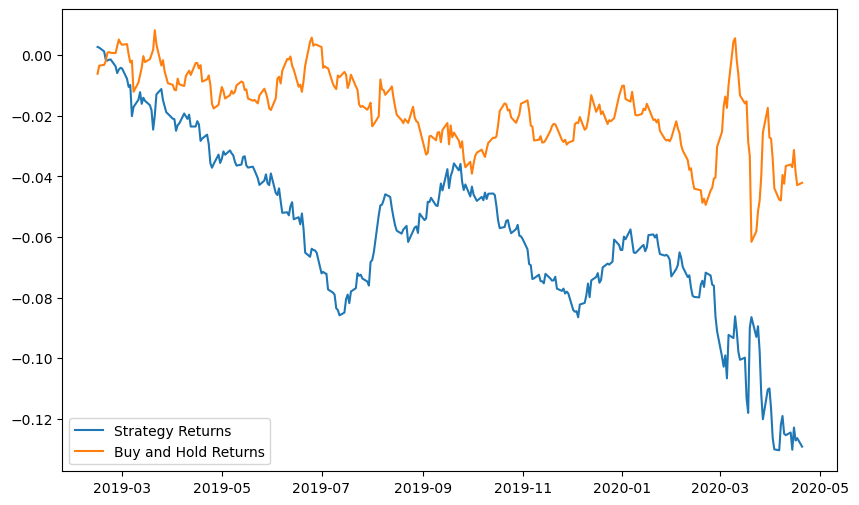

,Open,High,Low,Close,Adj Close,Volume,STD_5,STD_10,STD_15,STD_20,...,middle_band,lower_band,macd,macd_signal,macd_hist,SAR,returns,target,predicted,strategy_returns
Date,,,,,,,,,,,,,,,,,,,,,
2019-02-14,1.126405,1.130825,1.125062,1.126494,1.126494,0,0.003396,0.006916,0.006950,0.006005,...,1.130833,1.124758,-0.003854,-0.002584,-0.001270,1.147230,-0.006170,1,1,0.002696
2019-02-15,1.129471,1.129816,1.123495,1.129535,1.129535,0,0.002949,0.006553,0.007093,0.006292,...,1.129965,1.124689,-0.003980,-0.002864,-0.001117,1.145456,0.002696,-1,-1,-0.000237
2019-02-18,1.129484,1.133414,1.129484,1.129803,1.129803,0,0.002616,0.005572,0.007343,0.006528,...,1.129440,1.124760,-0.004012,-0.003093,-0.000919,1.143260,0.000237,1,-1,-0.001232
2019-02-19,1.131209,1.134185,1.127701,1.131196,1.131196,0,0.002546,0.004294,0.007329,0.006668,...,1.130099,1.125543,-0.003880,-0.003251,-0.000630,1.141283,0.001232,1,-1,-0.002741
2019-02-20,1.134301,1.136958,1.132593,1.134301,1.134301,0,0.002834,0.003144,0.007087,0.006694,...,1.130266,1.125196,-0.003485,-0.003298,-0.000188,1.139505,0.002741,-1,-1,-0.000295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-04-14,1.091953,1.098394,1.091572,1.092299,1.092299,0,0.002890,0.006930,0.009959,0.012261,...,1.090838,1.085668,-0.003208,-0.003486,0.000278,1.082478,-0.000885,1,-1,-0.005696
2020-04-15,1.098237,1.098901,1.085765,1.098539,1.098539,0,0.004321,0.006161,0.009447,0.012128,...,1.092642,1.084913,-0.002411,-0.003271,0.000859,1.083730,0.005696,-1,-1,0.007335
2020-04-16,1.090382,1.090774,1.082966,1.090510,1.090510,0,0.003017,0.005820,0.009398,0.012037,...,1.093471,1.088075,-0.002401,-0.003097,0.000696,1.113784,-0.007335,1,1,-0.004285


In [52]:
backtest_data = pd.read_csv("MLT03_data_EURUSD_backtest.csv",parse_dates = True,index_col = 0)
df_backtest1,bnh_returns, strategy_returns = backtest(backtest_data,model)

df_backtest1

In [53]:
print(f"BnH returns {bnh_returns}")
print(f"Strategy_returns {strategy_returns}")

BnH returns -0.044937002315672055
Strategy_returns -0.12920502327689393
